# BioVision-Path
## Histopathology Image Patch Classification using Deep Learning

### OBJECTIVE
This notebook implements a complete, technically rigorous histopathology image patch classification pipeline using the MedMNIST PathMNIST dataset (colorectal H&E patches, 9 tissue categories). 
We will:
1. Load PathMNIST data at 224x224 (MedMNIST+) and perform dataset verification and data quality checks.
2. Train a custom Baseline CNN from scratch to establish a performance baseline.
3. Fine-tune a pretrained ResNet-18 model using transfer learning.
4. Compare training curves, generate confusion matrices, and perform confidence analysis for error evaluation.

*Disclaimer: This project is for educational/research purposes and is not a clinical diagnostic system.*

### 1. Setup & Environment Detection

In [1]:
# Environment Report & CUDA Detection
import sys
import torch
import torchvision
from src.reproducibility import print_environment_report, set_seed
from src.config import CONFIG

# Print report
env = print_environment_report()
set_seed(CONFIG["seed"])


                    ENVIRONMENT REPORT                    
Python Version    : 3.10.9
PyTorch Version   : 2.13.0+cpu
CUDA Available    : False
GPU Name          : None (CPU Fallback)
[Notice] CUDA is not available. System is running in CPU fallback mode.
         In GPU environments (like Colab GPU runtime), this will significantly slow training.
         Please check runtime settings if a GPU was expected.
[Reproducibility] Random seed set to: 42


### 2. Dataset Verification & Validation

Dataset Name: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
Task type   : multi-class
Number of classes: 9


E:\BioVision\src\visualization.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts, palette="viridis")


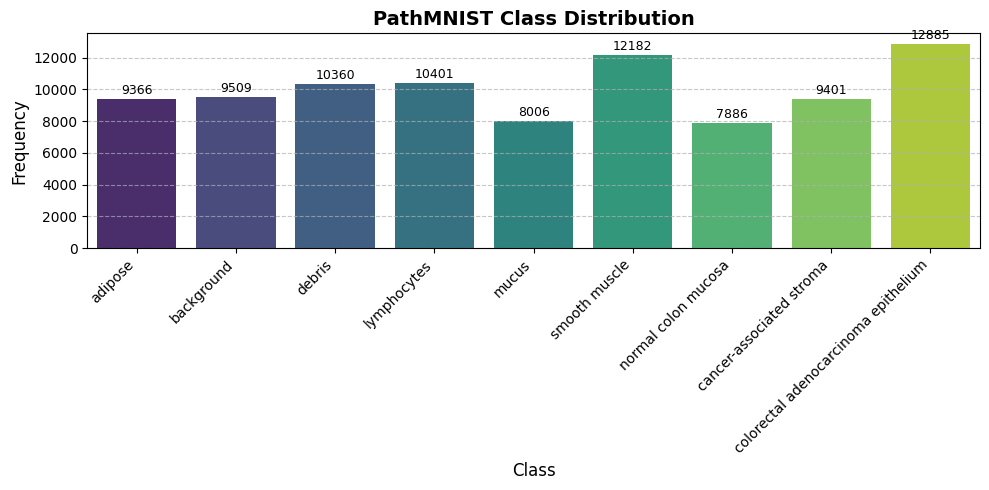

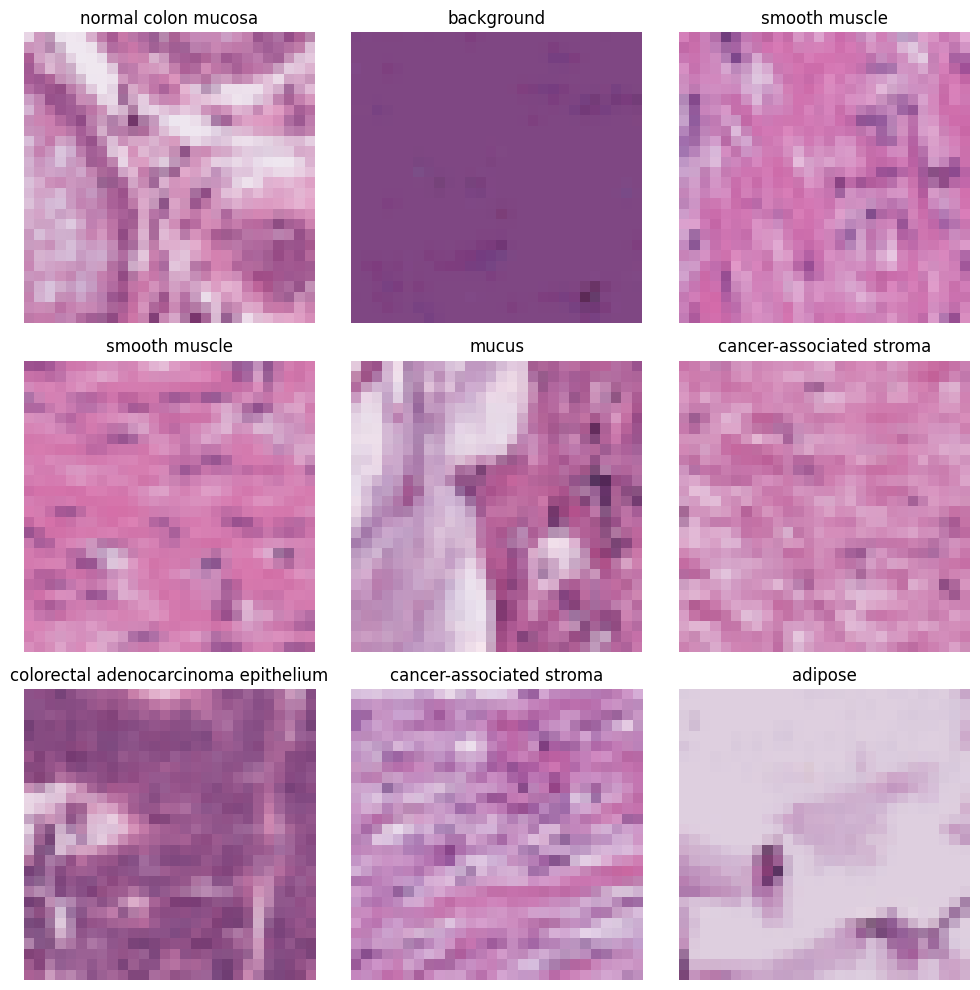

In [2]:
# Dataset Loading & Metadata check
import medmnist
from src.data import get_pathmnist_metadata, get_pathmnist_dataloaders, get_class_distribution, load_pathmnist_dataset
from src.preprocessing import get_classification_transforms, validate_tensor
from src.visualization import plot_dataset_montage, plot_class_distribution

# Get metadata
meta = get_pathmnist_metadata()
print(f"Dataset Name: {meta['name']}")
print(f"Task type   : {meta['task']}")
print(f"Number of classes: {meta['n_classes']}")

# Load full train dataset for metadata inspect
train_ds = load_pathmnist_dataset(split="train", size=CONFIG["classification"]["image_size"])
dist = get_class_distribution(train_ds)

# Plot distributions and sample montage
plot_class_distribution(dist, meta["classes"], title="PathMNIST Class Distribution", save_path="outputs/classification/class_distribution.png")
plot_dataset_montage(train_ds, meta["classes"], num_samples=9, save_path="outputs/classification/dataset_montage.png")


In [3]:
# Preprocessing Transforms & Dataloaders
train_trans, val_trans = get_classification_transforms(CONFIG["classification"]["image_size"])

# Get DataLoaders (using CONFIG['demo_mode'] for pipeline verification)
train_loader, val_loader, test_loader = get_pathmnist_dataloaders(
    batch_size=CONFIG["classification"]["demo"]["batch_size"] if CONFIG["demo_mode"] else CONFIG["classification"]["full"]["batch_size"],
    size=CONFIG["classification"]["image_size"],
    train_transform=train_trans,
    val_transform=val_trans,
    test_transform=val_trans,
    demo_mode=CONFIG["demo_mode"],
    subset_size=CONFIG["classification"]["demo"]["subset_size"]
)

# Run Image Quality Check on first batch
images, labels = next(iter(train_loader))
assert validate_tensor(images, "Batch Images"), "Data contains NaNs or Infs!"
print(f"Data validation passed. Batch images shape: {images.shape}")


[Data] DEMO MODE: Subsetting datasets. Train: 500, Val: 250, Test: 250


Data validation passed. Batch images shape: torch.Size([16, 3, 224, 224])


### 3. Model Implementations & Training

In [4]:
# 3.1 Custom Baseline CNN
from src.models import BaselineCNN
from src.training import fit_model
import torch.nn as nn
import torch.optim as optim

baseline_model = BaselineCNN(num_classes=meta["n_classes"]).to(CONFIG["device"])
optimizer = optim.AdamW(baseline_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Train Baseline
baseline_history = fit_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=CONFIG["classification"]["demo"]["epochs"] if CONFIG["demo_mode"] else CONFIG["classification"]["full"]["epochs"],
    device=CONFIG["device"],
    checkpoint_path="checkpoints/baseline_cnn.pth",
    task_type="classification"
)


[Training] Starting training on device: cpu (Task: classification)


Training Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Training Batches:   3%|▎         | 1/32 [00:00<00:14,  2.16it/s]

Training Batches:   6%|▋         | 2/32 [00:00<00:13,  2.18it/s]

Training Batches:   9%|▉         | 3/32 [00:01<00:13,  2.16it/s]

...

Validation Batches:  81%|████████▏ | 13/16 [00:02<00:00,  5.91it/s]

Validation Batches:  88%|████████▊ | 14/16 [00:02<00:00,  5.95it/s]

Validation Batches:  94%|█████████▍| 15/16 [00:02<00:00,  5.85it/s]

Validation Batches: 100%|██████████| 16/16 [00:02<00:00,  6.64it/s]

Epoch 1/1 | Train Loss: 1.9594 | Train Acc: 0.3060 | Val Loss: 1.7958 | Val Acc: 0.3800 | Time: 20.6s
 => State saved! New best loss: 1.7958
[Training] Restoring best checkpoint from: checkpoints/baseline_cnn.pth


In [5]:
# 3.2 Primary ResNet-18 Model
from src.models import get_resnet18_model

resnet_model = get_resnet18_model(num_classes=meta["n_classes"], pretrained=True).to(CONFIG["device"])
optimizer = optim.AdamW(resnet_model.parameters(), lr=1e-4)

# Train ResNet-18
resnet_history = fit_model(
    model=resnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=CONFIG["classification"]["demo"]["epochs"] if CONFIG["demo_mode"] else CONFIG["classification"]["full"]["epochs"],
    device=CONFIG["device"],
    checkpoint_path="checkpoints/resnet18_classification.pth",
    task_type="classification"
)


[Training] Starting training on device: cpu (Task: classification)


Training Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Training Batches:   3%|▎         | 1/32 [00:01<01:00,  1.95s/it]

Training Batches:   6%|▋         | 2/32 [00:03<00:57,  1.93s/it]

Training Batches:   9%|▉         | 3/32 [00:05<00:56,  1.94s/it]

...

Validation Batches:  81%|████████▏ | 13/16 [00:07<00:01,  1.80it/s]

Validation Batches:  88%|████████▊ | 14/16 [00:07<00:01,  1.79it/s]

Validation Batches:  94%|█████████▍| 15/16 [00:08<00:00,  1.79it/s]

Validation Batches: 100%|██████████| 16/16 [00:08<00:00,  1.96it/s]

Epoch 1/1 | Train Loss: 1.4429 | Train Acc: 0.5260 | Val Loss: 1.0459 | Val Acc: 0.5960 | Time: 67.7s
 => State saved! New best loss: 1.0459
[Training] Restoring best checkpoint from: checkpoints/resnet18_classification.pth


### 4. Quantitative Evaluation & Metrics

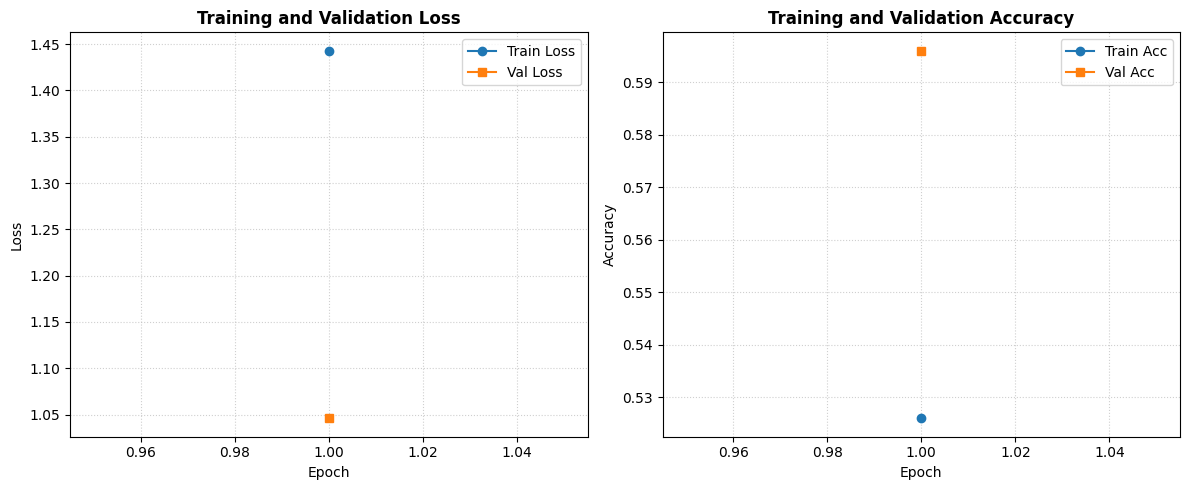

In [6]:
# Plot training history curves
from src.visualization import plot_training_curves
plot_training_curves(resnet_history, save_path="outputs/classification/training_curves.png")


--- ResNet-18 Test Evaluation Summary ---
accuracy            : 0.7400
macro_precision     : 0.8021
macro_recall        : 0.6958
macro_f1            : 0.6748
weighted_precision  : 0.8419
weighted_recall     : 0.7400
weighted_f1         : 0.7208


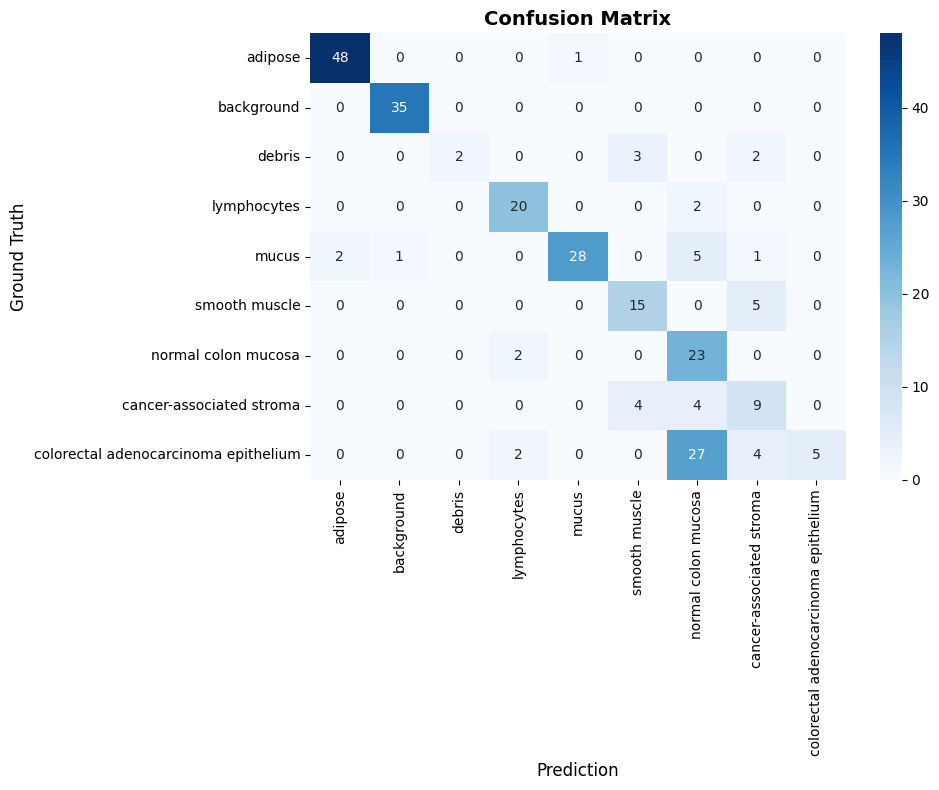

In [7]:
# Test Evaluation on ResNet-18
from src.evaluation import evaluate_classifier
from src.visualization import plot_confusion_matrix_sns

metrics, per_class, y_true, y_pred, y_prob = evaluate_classifier(resnet_model, test_loader, CONFIG["device"])

print("--- ResNet-18 Test Evaluation Summary ---")
for k, v in metrics.items():
    print(f"{k:20s}: {v:.4f}")

# Plot confusion matrix
plot_confusion_matrix_sns(y_true, y_pred, meta["classes"], save_path="outputs/classification/confusion_matrix.png")


### 5. Confidence Analysis

In [8]:
# Identify high-confidence correct vs incorrect predictions
import matplotlib.pyplot as plt
import numpy as np

correct = (y_true == y_pred)
confidences = np.max(y_prob, axis=1)

# Get indices
correct_indices = np.where(correct)[0]
incorrect_indices = np.where(~correct)[0]

# Sort by confidence
high_conf_correct = correct_indices[np.argsort(confidences[correct_indices])[-3:]]
low_conf_correct = correct_indices[np.argsort(confidences[correct_indices])[:3]]

print(f"High confidence correct indices: {high_conf_correct} (Confidences: {confidences[high_conf_correct]})")
if len(incorrect_indices) > 0:
    high_conf_incorrect = incorrect_indices[np.argsort(confidences[incorrect_indices])[-3:]]
    print(f"High confidence incorrect indices: {high_conf_incorrect} (Confidences: {confidences[high_conf_incorrect]})")
else:
    print("No incorrect predictions to show in this demo run.")


High confidence correct indices: [224 233 184] (Confidences: [0.99984455 0.99985266 0.99990404])
High confidence incorrect indices: [ 19 170 130] (Confidences: [0.72401524 0.7445799  0.8459371 ])


### 6. Limitations & Responsible Use
- **educational/research purpose**: This notebook is developed strictly as a computer vision benchmarking demonstration and is not medically validated.
- **limited generalization**: The model is trained on pre-cropped image patches and may not generalize to raw scanner slides, different staining protocols, or clinical domain shifts.
- **no clinical diagnostic capability**: It must NOT be used for patient care or medical decision-making.